# **Mobile Price Prediction** #

**Group Members:**
- 2602063674 - Raditya Noven
- 2440112986 - Fitria Ismiarti

**Problem Background**

Everyone use mobiles nowadays, but not all of them are aware of on how to choose the correct one. Predicting mobile prices through classification involves assigning a specific price range or category to each mobile device based on its features. One potential background problem in mobile price prediction classification is the selection and extraction of relevant features for accurate predictions.


**Data Description**

- `battery_power`: Total energy a battery can store in one time measured in mAh
- `blue`: Has bluetooth or not
- `clock_speed`: speed at which microprocessor executes instructions
- `dual_sim`: Has dual sim support or not
- `fc`: Front Camera mega pixels
- `four_g`: Has 4G or not
- `int_memory`: Internal Memory in Gigabytes
- `m_dep`: Mobile Depth in cm
- `mobile_wt`: Weight of mobile phone
- `n_cores`: Number of cores of processor
- `pc`: Primary Camera mega pixels
- `px_height`: Pixel Resolution Height
- `px_width`: Pixel Resolution Width
- `ram`: Random Access Memory in Mega Byte
- `sc_h`: Screen Height of mobile in cm
- `sc_w`: Screen Width of mobile in cm
- `talk_time`: longest time that a single battery charge will last when you are
- `three_g`: Has 3G or not
- `touch_screen`: Has touch screen or not
- `wifi`: Has wifi or not
- `price_range`: This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).

In [2]:
# Data Analysis and Preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Metrics, Model Selection, Machine Learning Models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix


warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('aol ml.csv')

## 1) Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

From the information, we can see that our dataset contains **2000 rows** and **21 columns**

In [6]:
# Display the first few rows of the dataset
print(df.head())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

In [7]:
# Display the last few rows of the dataset
print(df.tail())

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
1995            794     1          0.5         1   0       1           2   
1996           1965     1          2.6         1   0       0          39   
1997           1911     0          0.9         1   1       1          36   
1998           1512     0          0.9         0   4       1          46   
1999            510     1          2.0         1   5       1          45   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  \
1995    0.8        106        6  ...       1222      1890   668    13     4   
1996    0.2        187        4  ...        915      1965  2032    11    10   
1997    0.7        108        8  ...        868      1632  3057     9     1   
1998    0.1        145        5  ...        336       670   869    18    10   
1999    0.9        168        6  ...        483       754  3919    19     4   

      talk_time  three_g  touch_screen  wifi  price_range  
1995    

In [8]:
# Display the shape of the data
df.shape

(2000, 21)

In [60]:
# Sort the DataFrame based on the 'RAM' column in descending order
sorted_df = df.sort_values(by='ram', ascending=False)

# Display the sorted DataFrame
print(sorted_df)

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
940            1456     0          1.6         1   9       1          39   
1816            584     1          1.7         1   1       1          19   
69             1166     0          1.5         1   0       1          43   
1684           1035     0          0.5         1  14       1          49   
799            1567     0          2.1         1   3       0          22   
...             ...   ...          ...       ...  ..     ...         ...   
1224           1515     0          2.6         0   0       1          56   
1230            697     0          2.7         1   5       1          20   
467            1433     0          1.6         0   7       0           4   
1389           1801     0          0.5         1   6       0          52   
1745            926     1          0.8         0   6       1          59   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  \
940     

From the information, we can see that our dataset contains **2000 rows** and **21 columns**

In [9]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [10]:
# Check for missing values
print(df.isnull().sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


##### There is no missing values in the data

### Count the occurrences of unique values in every column

In [12]:
df['battery_power'].value_counts()

battery_power
1872    6
618     6
1589    6
1715    5
1807    5
       ..
660     1
1452    1
1005    1
1372    1
858     1
Name: count, Length: 1094, dtype: int64

In [13]:
df['blue'].value_counts()

blue
0    1010
1     990
Name: count, dtype: int64

In [14]:
df['clock_speed'].value_counts()

clock_speed
0.5    413
2.8     85
2.3     78
2.1     76
1.6     76
2.5     74
0.6     74
1.4     70
1.3     68
1.5     67
2.0     67
1.9     65
0.7     64
2.9     62
1.8     62
1.0     61
1.7     60
2.2     59
0.9     58
2.4     58
0.8     58
1.2     56
2.6     55
2.7     55
1.1     51
3.0     28
Name: count, dtype: int64

In [15]:
df['dual_sim'].value_counts()

dual_sim
1    1019
0     981
Name: count, dtype: int64

In [16]:
df['fc'].value_counts()

fc
0     474
1     245
2     189
3     170
5     139
4     133
6     112
7     100
9      78
8      77
10     62
11     51
12     45
13     40
16     24
15     23
14     20
18     11
17      6
19      1
Name: count, dtype: int64

In [17]:
df['four_g'].value_counts()

four_g
1    1043
0     957
Name: count, dtype: int64

In [18]:
df['int_memory'].value_counts()

int_memory
27    47
16    45
14    45
57    42
2     42
      ..
22    24
38    23
62    21
4     20
59    18
Name: count, Length: 63, dtype: int64

In [19]:
df['m_dep'].value_counts()

m_dep
0.1    320
0.2    213
0.8    208
0.5    205
0.7    200
0.3    199
0.9    195
0.6    186
0.4    168
1.0    106
Name: count, dtype: int64

In [20]:
df['mobile_wt'].value_counts()

mobile_wt
182    28
101    27
185    27
146    26
199    26
       ..
116    10
140     9
120     9
149     9
96      9
Name: count, Length: 121, dtype: int64

In [21]:
df['n_cores'].value_counts()

n_cores
4    274
7    259
8    256
2    247
3    246
5    246
1    242
6    230
Name: count, dtype: int64

In [22]:
df['pc'].value_counts()

pc
10    122
7     119
9     112
20    110
1     104
14    104
0     101
2      99
17     99
6      95
4      95
3      93
15     92
12     90
8      89
16     88
13     85
19     83
18     82
11     79
5      59
Name: count, dtype: int64

In [23]:
df['px_height'].value_counts()

px_height
347    7
179    6
371    6
275    6
674    5
      ..
87     1
648    1
341    1
993    1
483    1
Name: count, Length: 1137, dtype: int64

In [24]:
df['px_width'].value_counts()

px_width
874     7
1247    7
1383    6
1463    6
1469    6
       ..
1125    1
1367    1
1569    1
1481    1
1632    1
Name: count, Length: 1109, dtype: int64

In [25]:
df['ram'].value_counts()

ram
1464    4
3142    4
2610    4
2227    4
1229    4
       ..
2312    1
2167    1
3508    1
297     1
3919    1
Name: count, Length: 1562, dtype: int64

In [26]:
df['sc_h'].value_counts()

sc_h
17    193
12    157
7     151
16    143
14    143
15    135
13    131
11    126
10    125
9     124
19    124
18    120
8     117
6     114
5      97
Name: count, dtype: int64

In [27]:
df['sc_w'].value_counts()

sc_w
1     210
3     199
4     182
0     180
5     161
2     156
7     132
6     130
8     125
10    107
9      97
11     84
12     68
13     49
14     33
15     31
16     29
17     19
18      8
Name: count, dtype: int64

In [28]:
df['talk_time'].value_counts()

talk_time
7     124
4     123
16    116
15    115
19    113
6     111
10    105
8     104
11    103
20    102
14    101
13    100
18    100
9     100
2      99
12     99
17     98
3      94
5      93
Name: count, dtype: int64

In [29]:
df['three_g'].value_counts()

three_g
1    1523
0     477
Name: count, dtype: int64

In [30]:
df['touch_screen'].value_counts()

touch_screen
1    1006
0     994
Name: count, dtype: int64

In [31]:
df['wifi'].value_counts()

wifi
1    1014
0     986
Name: count, dtype: int64

In [32]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

'price_range' is the targetted feature

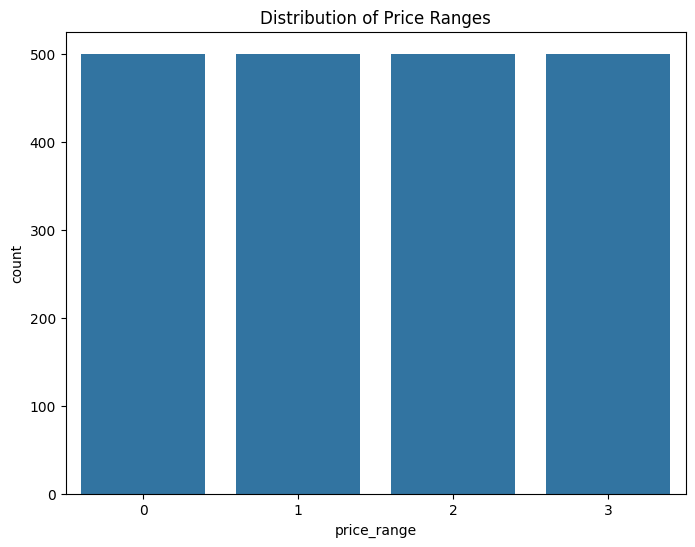

In [33]:
# Visualize the distribution of the target variable 'price_range'
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range', data=df)
plt.title('Distribution of Price Ranges')
plt.show()


## 2) Feature Engineering

In [34]:
# Check for missing values
print(df.isnull().sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


### There is no missing value

**Correlation Matrix**

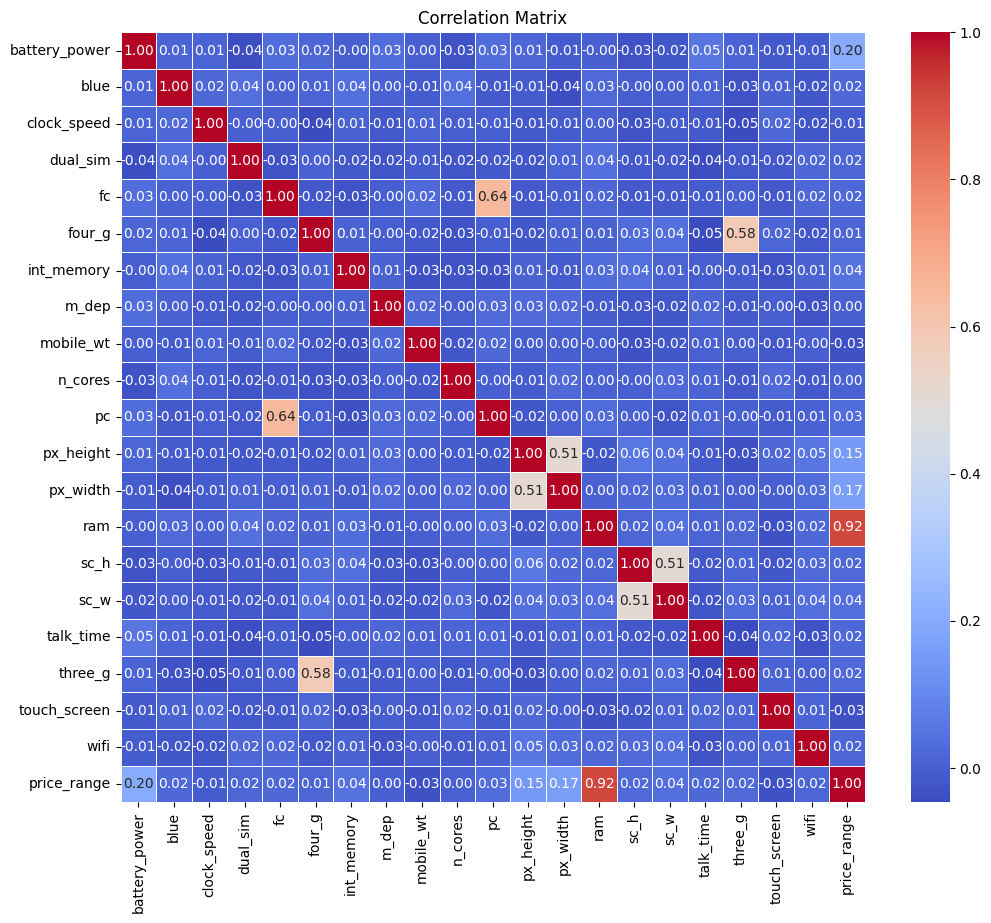

In [35]:
# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

##### The target feature is 'price_range'
##### With a correlation threshold of 0.1, the features that can be used are: 
##### - `px_height`          0.15
##### - `px_width`           0.17
##### - `battery_power`      0.20
##### - `ram`                0.92

In [36]:
new_feature = ['price_range', 'ram', 'px_width', 'px_height', 'battery_power']
new_df = df[new_feature]

##### Because there were too many dropped features, we created a new df with 5 features

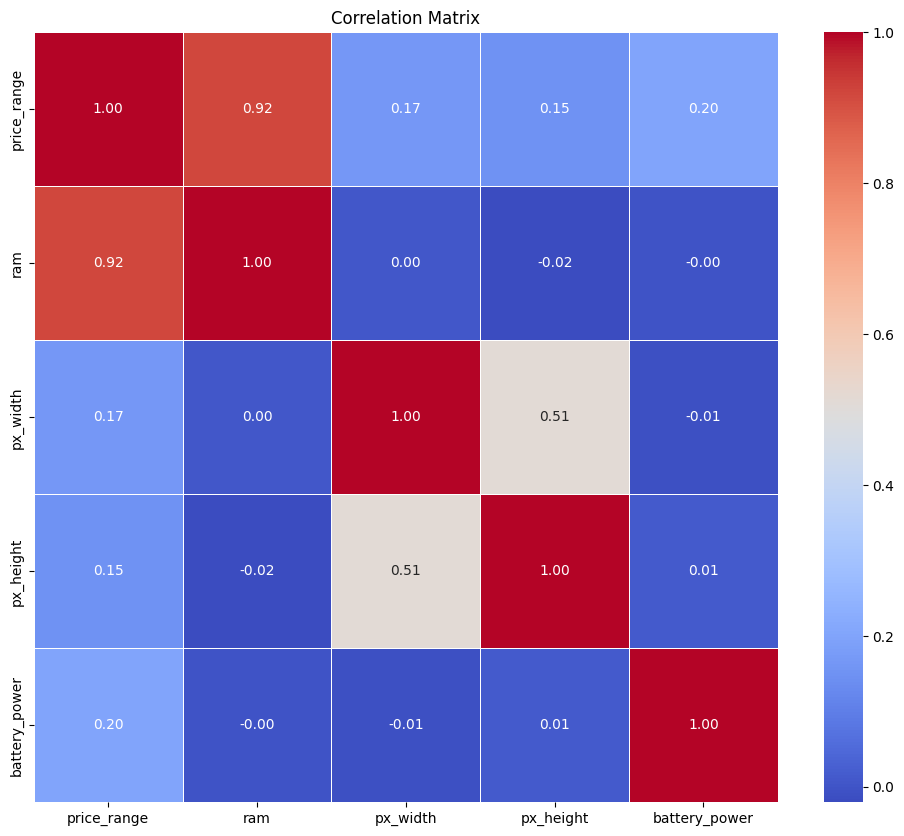

In [37]:
# Newer correlation matrix
correlation_matrix = new_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

##### Correlation table between 5 stored features

##### Independent features 'px_width' with 'px_height' have high dependency, therefore one of them will be dropped

In [38]:
# Drop feature 'px_width'
new_df = new_df.drop('px_width', axis=1)

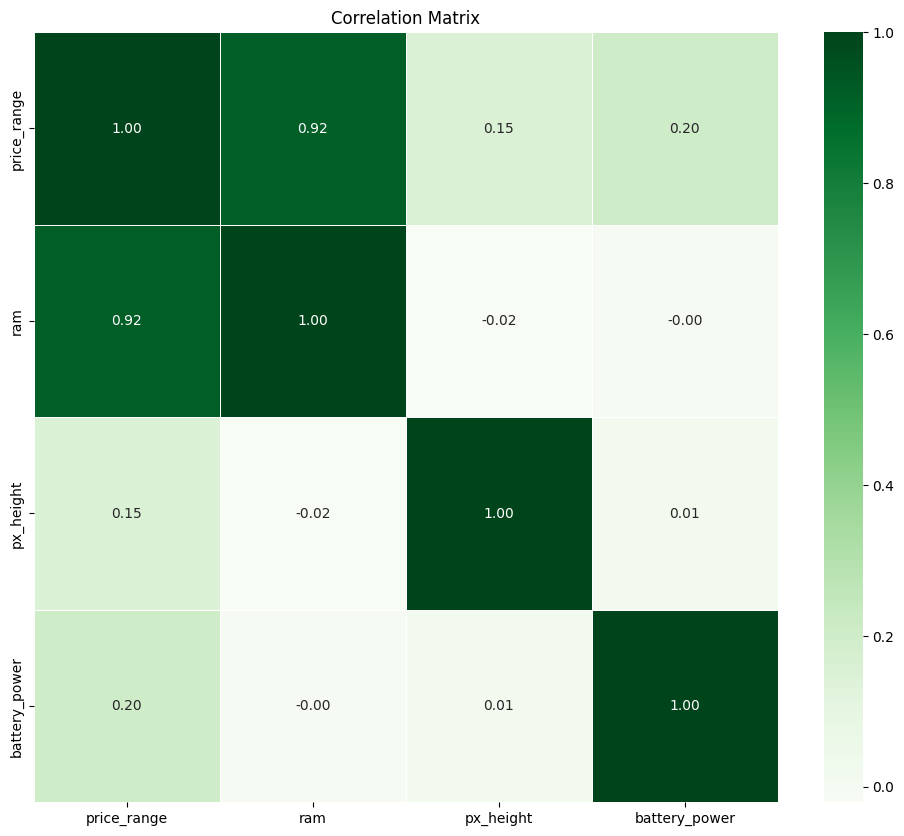

In [39]:
# Last correlation matrix
correlation_matrix = new_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

##### There are no independent features that have high dependency on each other anymore. Continue with these features

- **Data Splitting**

In [40]:
# Declaration

# X is the independent features
X = new_df.drop('price_range', axis = 1)

# Y is the dependent feature
y = new_df['price_range']

In [41]:
# Dependent feature value count
y.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

## 3 & 4) Training machine learning and evaluation

In [42]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

print(f'Train set = {len(X_train)}')
print(f'Test set  = {len(X_test)}\n')

Train set = 1500
Test set  = 500



### Machine Learning Modeling

#### A) Logistic Regression

In [43]:
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [44]:
# Fit the model to the training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

In [46]:
# Evaluate the performance of the model
accuracy = accuracy_score(y_test, y_pred)
classification_report_result = classification_report(y_test, y_pred)

# Display the results for 'Logistic Regression' accuracy
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report_result)

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       132
           1       0.86      0.90      0.88       118
           2       0.83      0.83      0.83       120
           3       0.91      0.89      0.90       130

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



In [47]:
# Display confusion matrix of 'Logistic Regression'
cm_logistic = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[124   8   0   0]
 [  5 106   7   0]
 [  0   9 100  11]
 [  0   0  14 116]]


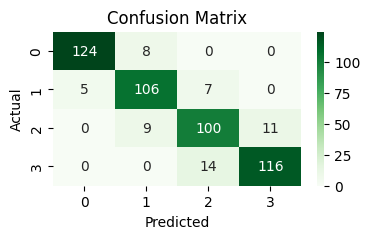

In [80]:
# Plot the confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### B) Support Vector Machine (SVM)

In [49]:
# Initialize the Logistic Regression model
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [50]:
# Fit the model to the training data
svm_classifier.fit(X_train, y_train)

SVC(random_state=42)

In [51]:
# Make predictions on the testing data
y_pred_svm = svm_classifier.predict(X_test)

In [52]:
# Evaluate the performance of the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
classification_report_result_svm = classification_report(y_test, y_pred_svm)

# Display the results for 'SVM' accuracy
print(f"Accuracy: {accuracy:.2f}")
print('\nClassification Report:')
print(classification_report_result_svm)

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       132
           1       0.85      0.91      0.88       118
           2       0.84      0.82      0.83       120
           3       0.91      0.89      0.90       130

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



In [53]:
# Display confusion matrix of 'SVM'
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[123   9   0   0]
 [  6 107   5   0]
 [  0  10  98  12]
 [  0   0  14 116]]


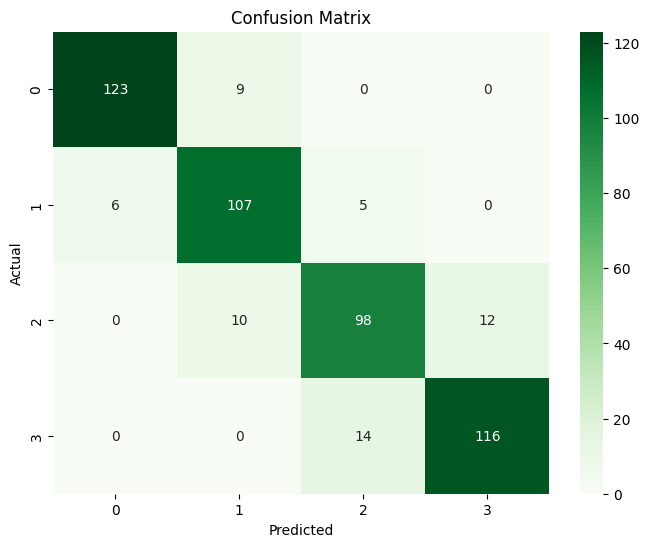

In [55]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From classification report, LogisticRegression and Suppport Vector Machine (SVM) model has the same level of accuracy, namely 89% or 0.89. But in this case, Logistic Regression has better performance than SVM because its precision is higher in some classes. So we decided to use logistic regression as the best classification model to apply to predict mobile prices.